<a href="https://colab.research.google.com/github/Priyadarshini-yadav13/Rashmi/blob/main/K_Mean_clustering_class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
## importing important libraries
import pandas as pd ##datamanupolation and dataframe creation
import numpy as np ## for numerical calculations
import matplotlib.pyplot as plt for data visualisation
import seaborn as sns for advance plotting

In [7]:
# loading the data
df=pd.read_csv('/content/drive/MyDrive/kmean/segmented_customers.csv')

In [8]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,3
2,3,Female,20,16,6,4
3,4,Female,23,16,77,3
4,5,Female,31,17,40,4
...,...,...,...,...,...,...
195,196,Female,35,120,79,1
196,197,Female,45,126,28,2
197,198,Male,32,126,74,1
198,199,Male,32,137,18,2


## Data summerisation

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
 5   cluster                 200 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 9.5+ KB


In [10]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),cluster
count,200.000000,200.000000,200.000000,200.000000,200.00000
mean,100.500000,38.850000,60.560000,50.200000,2.24500
std,57.879185,13.969007,26.264721,25.823522,1.81423
min,1.000000,18.000000,15.000000,1.000000,0.00000
25%,50.750000,28.750000,41.500000,34.750000,1.00000
50%,100.500000,36.000000,61.500000,50.000000,2.00000
75%,150.250000,49.000000,78.000000,73.000000,4.00000
max,200.000000,70.000000,137.000000,99.000000,5.00000


In [11]:
df.shape

(200, 6)

In [12]:
## preprocessing of data
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0
cluster,0


## there is no null values.

## Segregating the dataset into input

In [13]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,3
2,3,Female,20,16,6,4
3,4,Female,23,16,77,3
4,5,Female,31,17,40,4


In [14]:
df_=df[['Annual Income (k$)','Spending Score (1-100)']]

In [15]:
df_

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [16]:
X=df_.values

In [17]:
X

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

In [18]:
## finding the best k value by elbow method(wcss,within cluster sum os square)

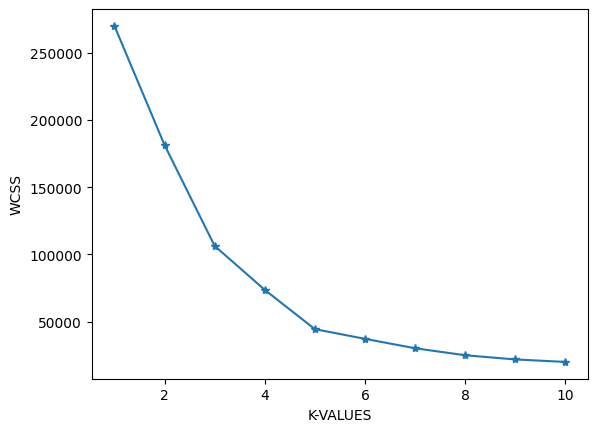

In [19]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
  model = KMeans(n_clusters = i, random_state=42, n_init=10)
  model.fit(df_)
  wcss.append(model.inertia_)

import matplotlib.pyplot as plt

plt.xlabel("K-VALUES")
plt.ylabel("WCSS") # Within Cluster Sum of Squares - Elbow Method
plt.plot(range(1,11),wcss,marker="*")
plt.show()

##k==5 is best value as it is on elbow point.

In [20]:
model=KMeans(n_clusters=5)


In [21]:
y=model.fit_predict(X)

##calculating the evaluation of data

In [22]:
from sklearn.metrics import silhouette_score

In [23]:
score=silhouette_score(X,y)

In [24]:
score

np.float64(0.4593850389758776)

## visualisation

In [25]:
model.cluster_centers_

array([[ 25.72727273,  79.36363636],
       [ 87.        ,  18.63157895],
       [ 47.96      ,  43.25      ],
       [ 77.72413793,  81.06896552],
       [108.18181818,  82.72727273]])

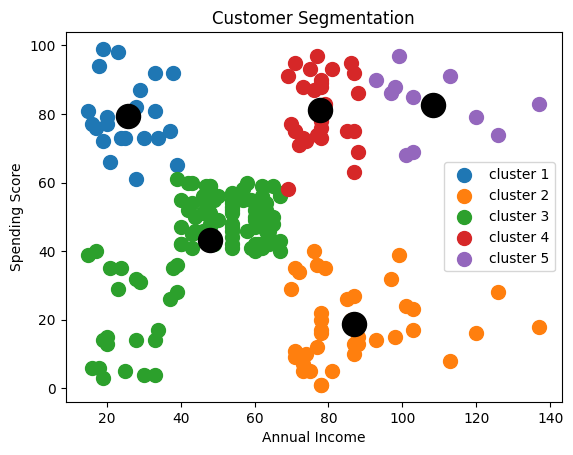

In [26]:
plt.scatter(X[y==0,0],X[y==0,1],s=100,label='cluster 1')##X[y==o,o]shows all value of X for which y(cluster)is o and first element of that
plt.scatter(X[y==1,0],X[y==1,1],s=100,label='cluster 2')
plt.scatter(X[y==2,0],X[y==2,1],s=100,label='cluster 3')
plt.scatter(X[y==3,0],X[y==3,1],s=100,label='cluster 4')
plt.scatter(X[y==4,0],X[y==4,1],s=100,label='cluster 5')
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1],c='black',s=300)
plt.title("Customer Segmentation")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()
plt.show()

##Data Diary Graph shows the relationship between spending score and annual income. This graph shows there are 5 clusters:
- Cluster one is having low annual income with more spending score.
- Cluster two is having high annual income plus low spending score.
- Cluster three is having moderate annual income with a moderate spending score.
- Cluster four is having more annual income with a high spending score.
Similarly, cluster four shows high annual income with high spending score, so we can use this matrix for recommendation. Our target will be cluster one and cluster four and cluster five. We'll totally concentrate on these clusters.

In [27]:
X


array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

In [37]:
c=0
for i in X:
  ##print(i)
    c=c+1
    if i[0]==126 and i[1]==28:
        print (i)
        print(c)

[126  28]
197


so X is having 126,28 on 197 position.

In [42]:
##now we will crosscheck it..will see that at 197 place what is the element
X[196]

array([126,  28])